---
jupytext:
  text_representation:
    format_name: myst
kernelspec:
  display_name: Python 3
  language: python
  name: python3
---

# 8. 悬链线与追踪曲线 Catenary & Pursuit

悬链线是自由悬挂的链条形状。追踪曲线描述了追逐问题的路径。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False

## 8.1 悬链线 Catenary

$y = a\cosh(x/a)$

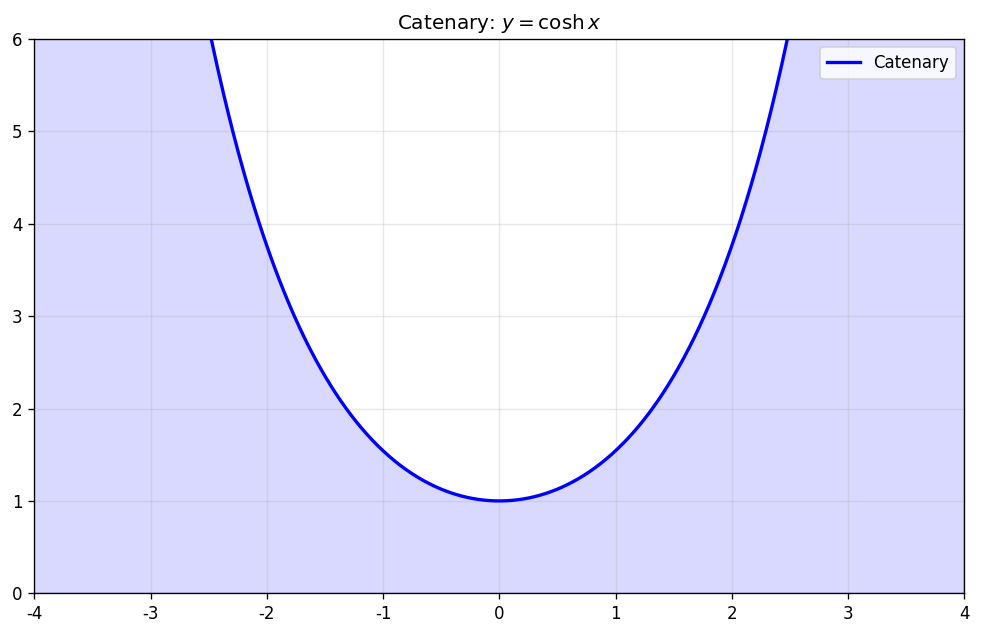

In [2]:
x = np.linspace(-4, 4, 2000)
a = 1
y = np.cosh(x/a)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, 'b-', linewidth=2, label='Catenary')
ax.fill_between(x, y, alpha=0.15, color='blue')
ax.set_title('Catenary: $y = \\cosh x$')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlim(-4, 4); ax.set_ylim(0, 6)
plt.show()

## 8.2 不同参数的悬链线

$a = 0.5, 1, 1.5, 2$

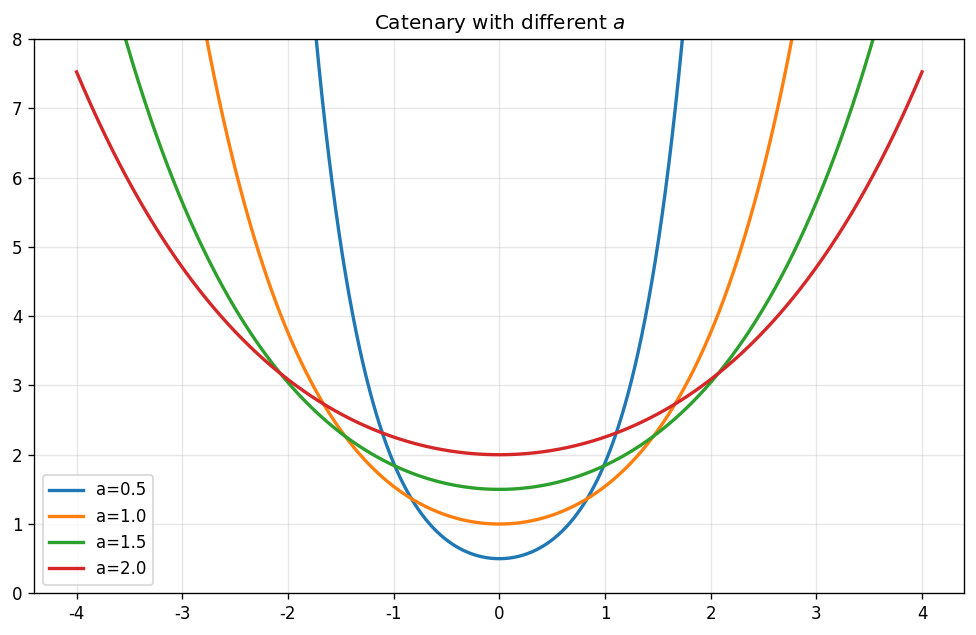

In [3]:
x = np.linspace(-4, 4, 2000)
fig, ax = plt.subplots(figsize=(10, 6))
for a in [0.5, 1.0, 1.5, 2.0]:
    y = a * np.cosh(x/a)
    ax.plot(x, y, linewidth=2, label=f'a={a}')
ax.set_title('Catenary with different $a$')
ax.set_ylim(0, 8); ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 8.3 追踪曲线 Tractrix

$x = t - \tanh t, \quad y = \operatorname{sech} t$

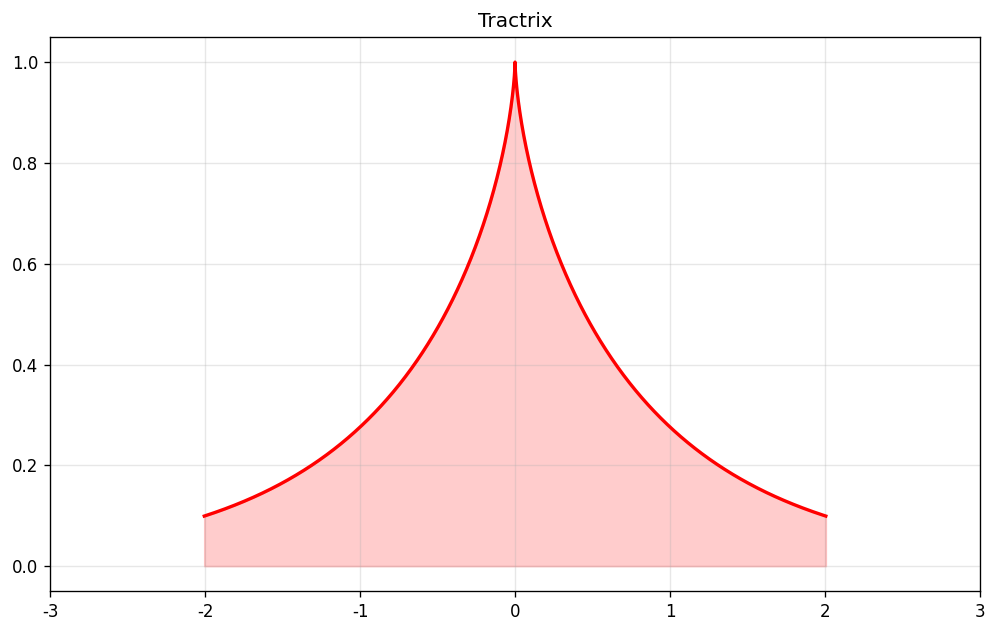

In [4]:
t = np.linspace(-3, 3, 2000)
x = t - np.tanh(t)
y = 1 / np.cosh(t)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, 'r-', linewidth=2)
ax.fill_between(x, y, alpha=0.2, color='red')
ax.set_title('Tractrix') # / 追踪曲线
ax.grid(True, alpha=0.3)
ax.set_xlim(-3, 3)
plt.show()

## 8.4 弹性曲线 Elastic Curve / Euler's Elastica

形状类似弹性杆弯曲。

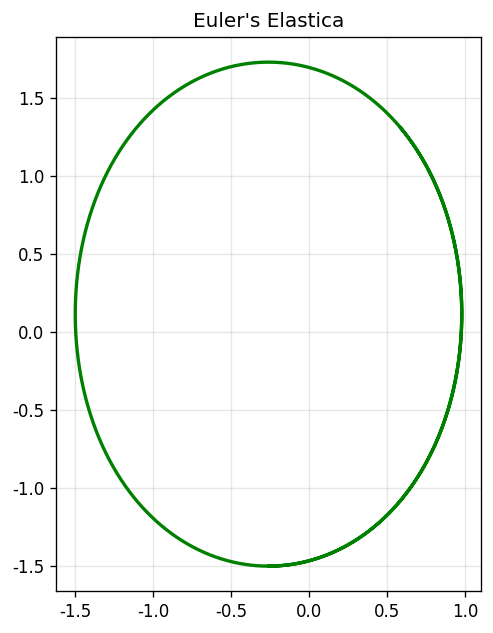

In [5]:
from scipy.special import ellipj
t = np.linspace(0, 4*np.pi, 5000)
m = 0.8
sn, cn, dn, _ = ellipj(t, m)
# Build elastica via integrals
x = np.cumsum(cn * np.gradient(t))
y = np.cumsum(sn * np.gradient(t))
x, y = x - x.mean(), y - y.mean()
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, 'green', linewidth=2)
ax.set_aspect('equal')
ax.set_title("Euler's Elastica") # / 弹性曲线
ax.grid(True, alpha=0.3)
plt.show()

## 8.5 匀速追踪曲线 Pursuit Curve

一只狗追逐跑步者的轨迹。

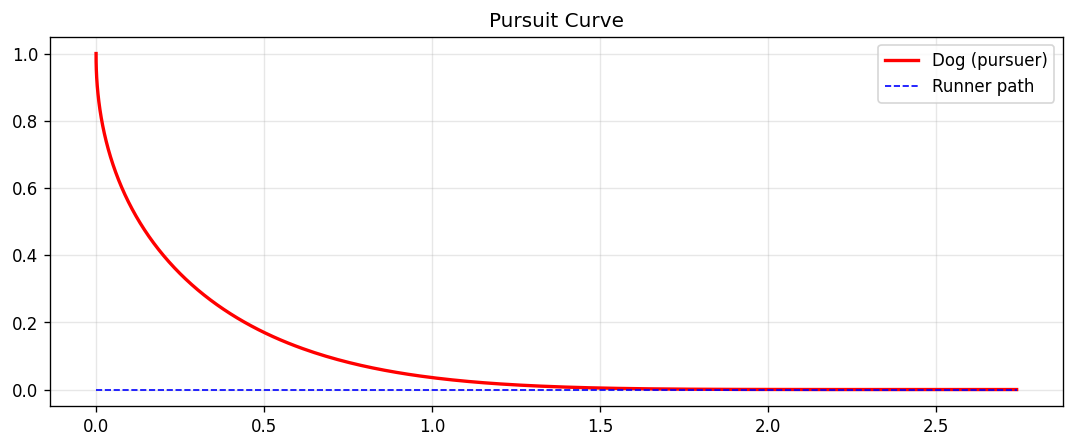

In [6]:
# Pursuit: runner at (vt, 0), dog starts at (0,1), speed ratio k
def pursuit_curve(k=1.5, n=1000):
    x_dog, y_dog = [0.0], [1.0]
    dt = 0.01
    for i in range(n):
        x_r = dt * i  # runner
        y_r = 0.0
        dx = x_r - x_dog[-1]
        dy = y_r - y_dog[-1]
        dist = np.sqrt(dx**2 + dy**2)
        if dist < 0.001: break
        x_dog.append(x_dog[-1] + k * dx/dist * dt)
        y_dog.append(y_dog[-1] + k * dy/dist * dt)
    return np.array(x_dog), np.array(y_dog)

x_d, y_d = pursuit_curve(k=1.2)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x_d, y_d, 'r-', linewidth=2, label='Dog (pursuer)')
ax.plot([0, x_d[-1]], [0, 0], 'b--', linewidth=1, label='Runner path')
ax.set_aspect('equal')
ax.set_title('Pursuit Curve') # / 追踪问题
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 8.6 拖曳曲线 Dragging Curve

类似于 Tractrix 但参数可调。

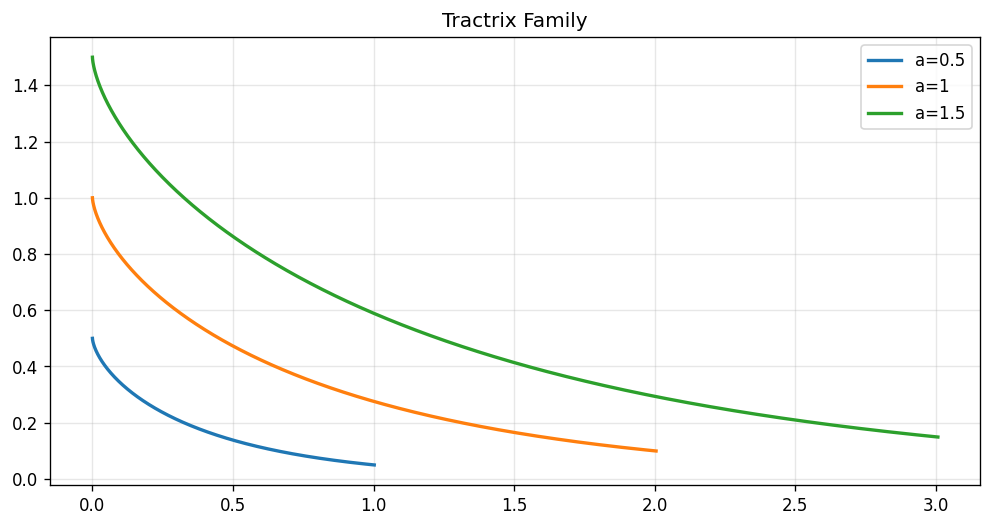

In [7]:
def tractrix_curve(a=1, L=4):
    t = np.linspace(0, 3, 1000)
    x = a * (t - np.tanh(t))
    y = a / np.cosh(t)
    return x, y, np.full_like(x, L)

fig, ax = plt.subplots(figsize=(10, 5))
for a in [0.5, 1, 1.5]:
    x, y, _ = tractrix_curve(a)
    ax.plot(x, y, linewidth=2, label=f'a={a}')
ax.set_aspect('equal')
ax.set_title('Tractrix Family')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()